# Day 17 — Remake
### #30DayChartChallenge | April 2026

**A Century and a Half of Warming.** A remake of Ed Hawkins' iconic *#ShowYourStripes* (2018). Each stripe = one year of global temperature anomaly, 1880–2025. Blue = cooler than the 1951–1980 baseline; red = warmer.

**Data:** NASA GISS Surface Temperature Analysis v4 (GISTEMP) — [Land‐Ocean Global Means](https://data.giss.nasa.gov/gistemp/)  
**Original concept:** Ed Hawkins, University of Reading — [#ShowYourStripes](https://showyourstripes.info)  
**Author:** Sharfudeen Yasar Arafath

In [1]:
# — packages ------------------------------------------------------------------

library(ggplot2)
library(dplyr)
library(showtext)
library(sysfonts)
library(scales)
library(RColorBrewer)


Attaching package: 'dplyr'




The following objects are masked from 'package:stats':

    filter, lag




The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




Loading required package: sysfonts



Loading required package: showtextdb



In [2]:
# — fonts & display size ------------------------------------------------------

font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
font_add_google("JetBrains Mono", "jetbrains")
showtext_auto()
showtext_opts(dpi = 300)

options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 300)

In [3]:
# — read data -----------------------------------------------------------------
# Source: NASA GISTEMP v4, Land–Ocean Global Means
# Annual mean (J–D column) in degrees Celsius vs 1951–1980 baseline.

raw <- read.csv("../../data/day_17/gistemp_global.csv",
                skip = 1, stringsAsFactors = FALSE, na.strings = c("***"))

df <- raw %>%
  select(year = Year, anomaly_c = J.D) %>%
  mutate(anomaly_c = as.numeric(anomaly_c)) %>%
  filter(!is.na(anomaly_c))

# Save tidy CSV alongside raw for reproducibility
write.csv(df, "../../data/day_17/global_temp_annual.csv", row.names = FALSE)

cat("Years:", min(df$year), "to", max(df$year),
    "(", nrow(df), "stripes)\n")
cat("Coolest:", df$year[which.min(df$anomaly_c)],
    "(", min(df$anomaly_c), "°C)\n")
cat("Warmest:", df$year[which.max(df$anomaly_c)],
    "(+", max(df$anomaly_c), "°C)\n")
cat("Latest:", df$year[nrow(df)],
    "(+", df$anomaly_c[nrow(df)], "°C)\n")

Years: 1880 to 2025 ( 146 stripes)


Coolest: 1909 ( -0.49 °C)


Warmest: 2024 (+ 1.28 °C)


Latest: 2025 (+ 1.19 °C)


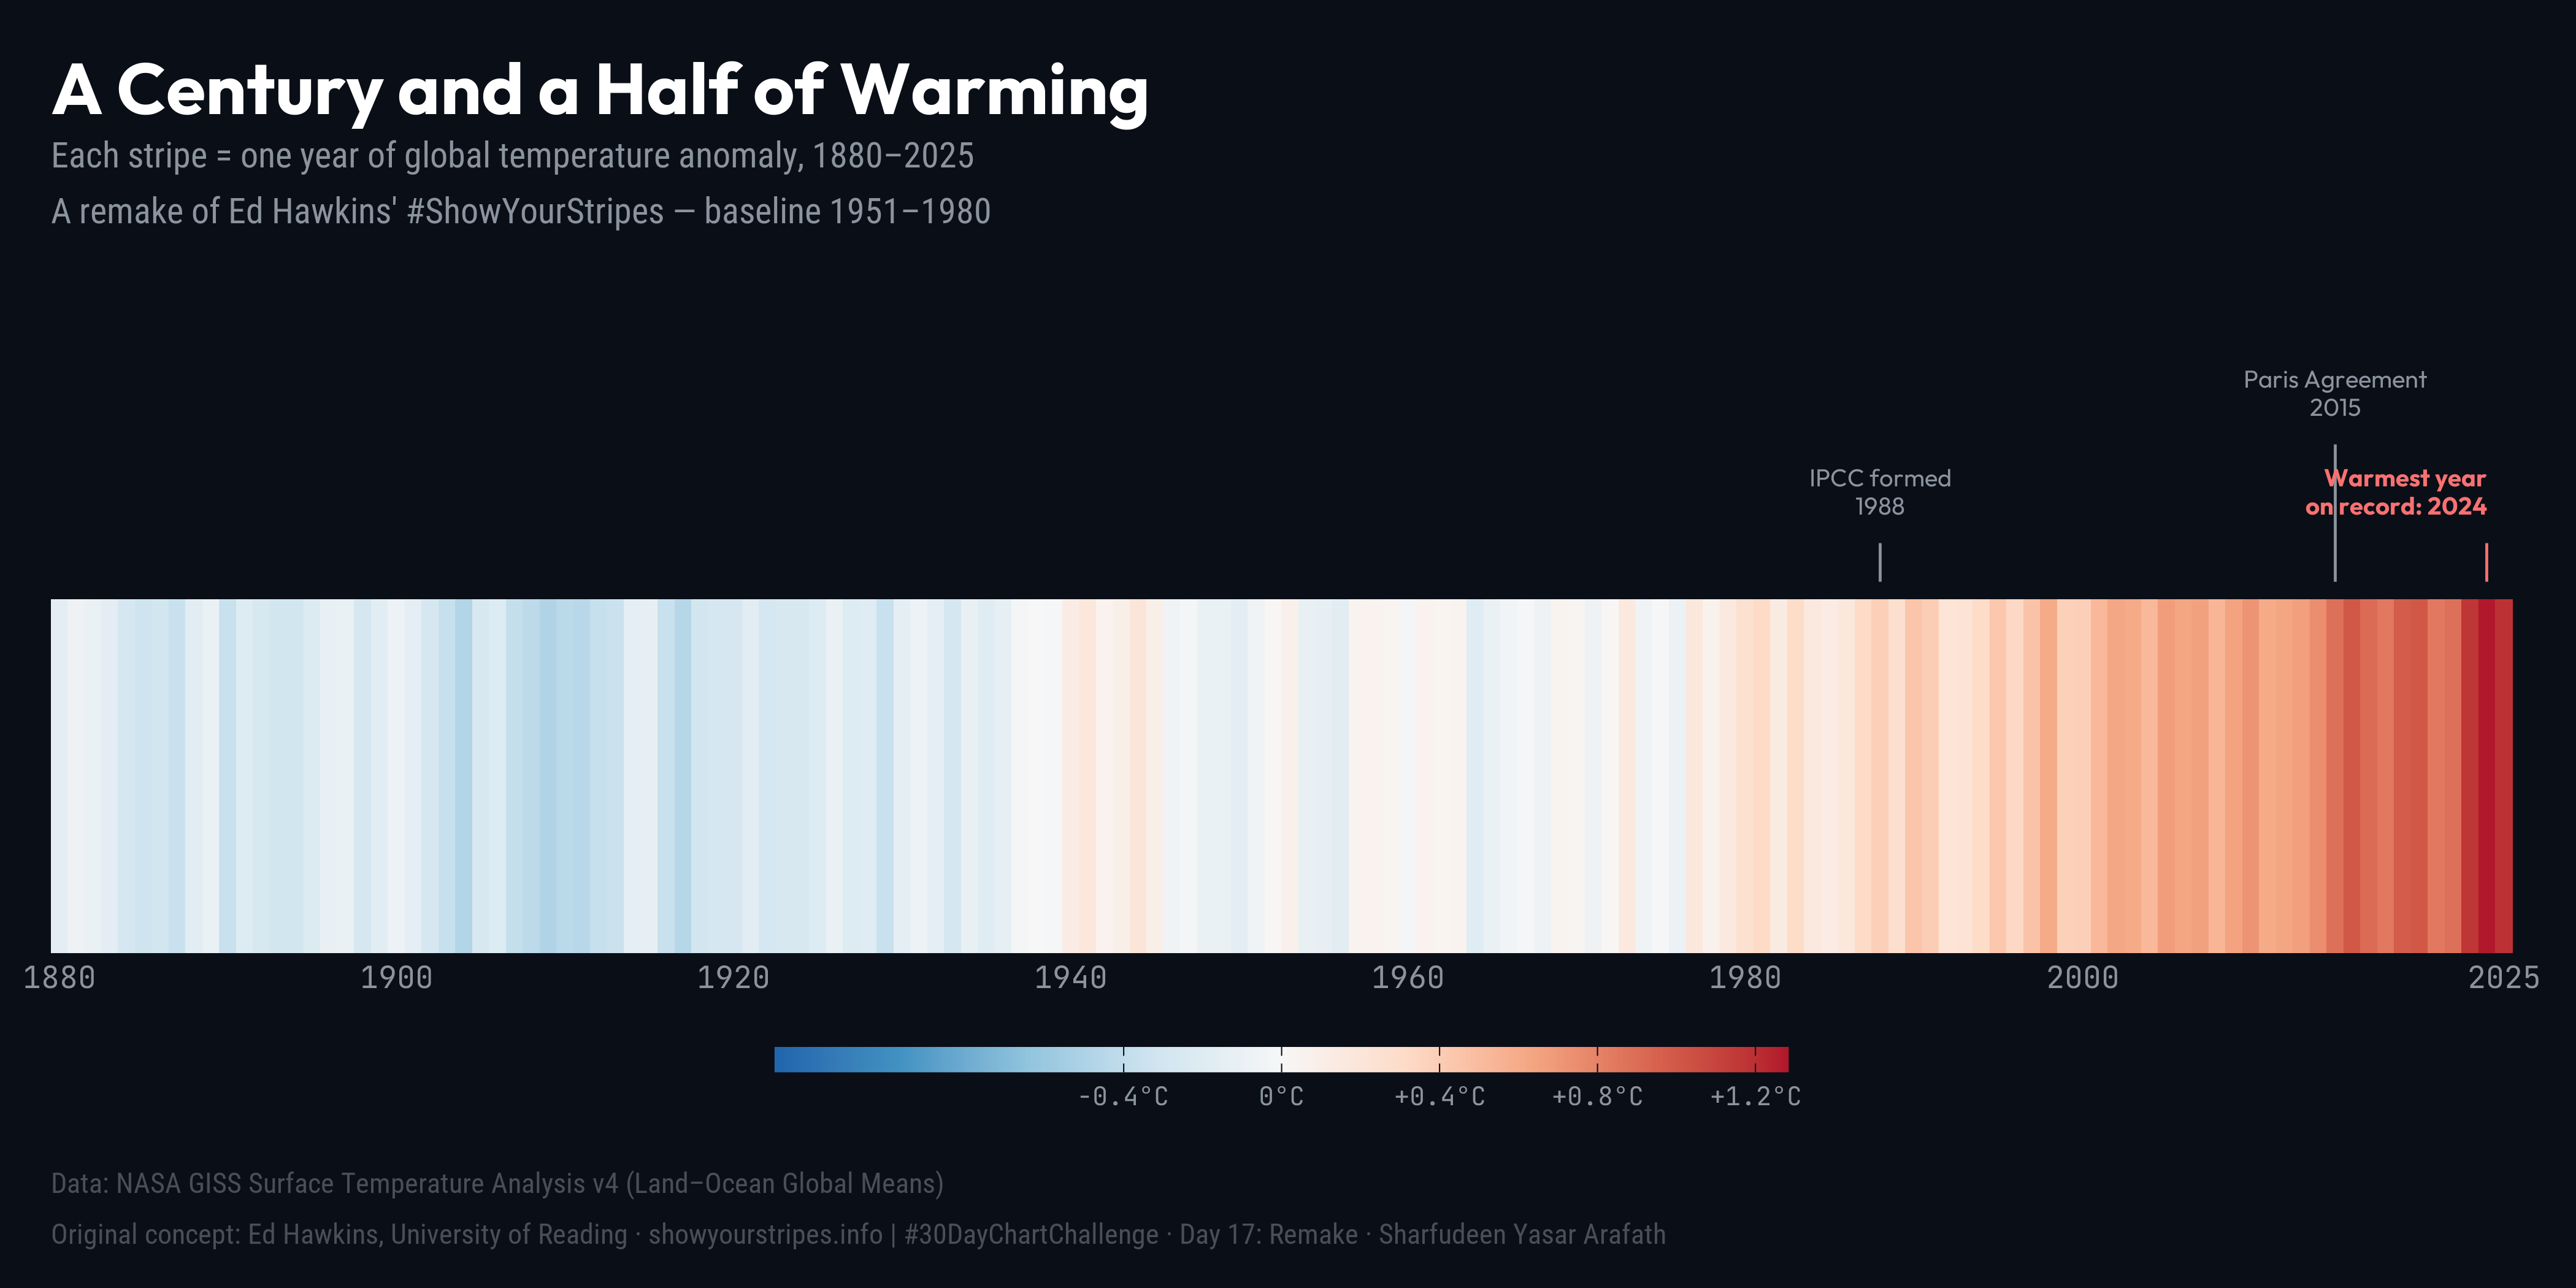

In [4]:
# — build the plot ------------------------------------------------------------

bg <- "#0a0e17"; txt <- "#E6EDF3"; txt_dim <- "#8B949E"
txt_cap <- "#484F58"

# Hawkins-style diverging palette (RdBu reversed) — 9 anchor colours
hawkins <- rev(brewer.pal(9, "RdBu"))

lim <- max(abs(df$anomaly_c))

yr_min <- min(df$year); yr_max <- max(df$year)
yr_breaks <- c(yr_min, seq(1900, 2000, 20), yr_max)

p <- ggplot(df, aes(x = year, y = 1, fill = anomaly_c)) +
  geom_tile() +
  scale_fill_gradientn(
    colours = hawkins,
    limits = c(-lim, lim),
    breaks = c(-0.4, 0, 0.4, 0.8, 1.2),
    labels = function(x) ifelse(x > 0, paste0("+", x, "\u00b0C"),
                                paste0(x, "\u00b0C")),
    name = NULL,
    guide = guide_colorbar(
      barwidth = unit(14, "cm"), barheight = unit(0.35, "cm"),
      ticks.colour = bg, frame.colour = NA,
      title.position = "top")) +

  # Milestone markers — staggered heights to avoid overlap on the right
  annotate("segment", x = 1988, xend = 1988,
    y = 1.55, yend = 1.66, color = txt_dim, linewidth = 0.4) +
  annotate("text", x = 1988, y = 1.74,
    label = "IPCC formed\n1988",
    family = "outfit", size = 3.4, color = txt_dim,
    lineheight = 0.95, vjust = 0) +

  annotate("segment", x = 2015, xend = 2015,
    y = 1.55, yend = 1.94, color = txt_dim, linewidth = 0.4) +
  annotate("text", x = 2015, y = 2.02,
    label = "Paris Agreement\n2015",
    family = "outfit", size = 3.4, color = txt_dim,
    lineheight = 0.95, vjust = 0) +

  annotate("segment", x = 2024, xend = 2024,
    y = 1.55, yend = 1.66, color = "#f87171", linewidth = 0.4) +
  annotate("text", x = 2024, y = 1.74,
    label = "Warmest year\non record: 2024",
    family = "outfit", fontface = "bold", size = 3.4,
    color = "#f87171", lineheight = 0.95, vjust = 0, hjust = 1) +

  scale_x_continuous(breaks = yr_breaks, expand = c(0, 0)) +
  scale_y_continuous(limits = c(0.5, 2.4), expand = c(0, 0)) +
  coord_cartesian(clip = "off") +

  labs(
    title = "A Century and a Half of Warming",
    subtitle = paste0(
      "Each stripe = one year of global temperature anomaly, 1880\u20132025\n",
      "A remake of Ed Hawkins' #ShowYourStripes \u2014 baseline 1951\u20131980"
    ),
    x = NULL, y = NULL,
    caption = paste0(
      "Data: NASA GISS Surface Temperature Analysis v4 (Land\u2013Ocean Global Means)\n",
      "Original concept: Ed Hawkins, University of Reading \u00b7 showyourstripes.info | ",
      "#30DayChartChallenge \u00b7 Day 17: Remake \u00b7 ",
      "Sharfudeen Yasar Arafath"
    )
  ) +

  theme_minimal(base_family = "roboto_condensed") +
  theme(
    plot.title = element_text(family = "outfit", face = "bold", size = 28,
      color = "#FFFFFF", margin = margin(t = 10, b = 5)),
    plot.subtitle = element_text(size = 14, color = txt_dim,
      lineheight = 1.3, margin = margin(b = 20)),
    plot.caption = element_text(size = 11, hjust = 0, color = txt_cap,
      lineheight = 1.5, margin = margin(t = 20)),
    axis.text.x = element_text(size = 12, color = txt_dim,
      family = "jetbrains", margin = margin(t = 6)),
    axis.text.y = element_blank(),
    axis.ticks = element_blank(),
    panel.grid = element_blank(),
    legend.position = "bottom",
    legend.text = element_text(size = 10, color = txt_dim,
      family = "jetbrains"),
    legend.margin = margin(t = 10, b = 5),
    plot.background = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = bg, color = NA),
    plot.margin = margin(15, 25, 15, 20)
  )

p

In [5]:
# — save ----------------------------------------------------------------------

ggsave("../../chart/day_17_remake.png",
       plot = p, width = 14, height = 7, dpi = 300, bg = bg)

cat("Done \u2014 saved to chart/day_17_remake.png\n")

Done — saved to chart/day_17_remake.png
